# EOD Zootopia - Exploitation des Résultats
## Analyse Comparative Dry / Normal / Wet
---

In [288]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Couleurs scénarios
colors = {'dry': '#E74C3C', 'normal': '#3498DB', 'wet': '#27AE60'}

# Charger les résultats
results = {}
for scenario in ['dry', 'normal', 'wet']:
    try:
        results[scenario] = pd.read_csv(f'../results/results_{scenario}.csv')
        print(f"✅ Scénario {scenario.upper()} : {len(results[scenario])} heures chargées")
    except FileNotFoundError:
        print(f"❌ Fichier results_{scenario}.csv non trouvé")

print(f"\nColonnes disponibles : {results['dry'].columns.tolist() if 'dry' in results else 'N/A'}")

✅ Scénario DRY : 8760 heures chargées
✅ Scénario NORMAL : 8760 heures chargées
✅ Scénario WET : 8760 heures chargées

Colonnes disponibles : ['hour', 'month', 'load', 'Phy_fdl', 'Phy_lac', 'P_nuc', 'P_charbon', 'P_ccg', 'P_tac', 'P_cogen', 'P_fioul', 'P_eolien', 'P_solaire', 'P_dechets', 'P_biomasse', 'stock_hydro', 'stock_STEP', 'Puns', 'Pspill', 'UC_nuc', 'UC_charbon', 'UC_ccg', 'UC_tac', 'UC_cogen', 'UC_fioul', 'Pcharge_STEP', 'Pdecharge_STEP', 'stock_hydro_min', 'stock_hydro_max', 'slack_seasonal', 'slack_stock_min', 'slack_stock_max', 'S_socle', 'S_surplus', 'inflows_lac', 'inflows_fdl', 'infeasible_flag', 'water_price', 'cost_nuc', 'cost_charbon', 'cost_ccg', 'cost_tac', 'cost_fioul']


## 1️⃣ RÉSUMÉ ANNUEL PAR SCÉNARIO

In [289]:
print("="*100)
print("📊 RÉSUMÉ ANNUEL - 3 SCÉNARIOS")
print("="*100)

summary = {}
for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    
    df = results[scenario]
    
    # Charges et productions
    load_total = df['load'].sum() / 1e6  # TWh
    hydro_lac = df['Phy_lac'].sum() / 1e6
    hydro_fdl = df['Phy_fdl'].sum() / 1e6
    hydro_total = hydro_lac + hydro_fdl
    
    # Thermique
    p_nuc = df['P_nuc'].sum() / 1e6
    p_charbon = df['P_charbon'].sum() / 1e6 if 'P_charbon' in df.columns else 0
    p_gaz = (df['P_ccg'].sum() + df['P_tac'].sum() + df['P_cogen'].sum()) / 1e6 if all(c in df.columns for c in ['P_ccg', 'P_tac', 'P_cogen']) else 0
    
    # ENR et bioénergies
    p_enr = (df['P_eolien'].sum() + df['P_solaire'].sum()) / 1e6 if all(c in df.columns for c in ['P_eolien', 'P_solaire']) else 0
    p_bio = (df['P_dechets'].sum() + df['P_biomasse'].sum()) / 1e6 if all(c in df.columns for c in ['P_dechets', 'P_biomasse']) else 0
    
    # Défaillance et stockage
    puns = df['Puns'].sum() / 1e6 if 'Puns' in df.columns else 0
    pspill = df['Pspill'].sum() / 1e6 if 'Pspill' in df.columns else 0
    step_turb = df['Pdecharge_STEP'].sum() / 1e6 if 'Pdecharge_STEP' in df.columns else 0
    
    # Stocks moyens
    stock_hydro_mean = df['stock_hydro'].mean() / 1e6
    stock_step_mean = df['stock_STEP'].mean() / 1e6 if 'stock_STEP' in df.columns else 0
    
    # Fiabilité
    fiabilite = 100 * (1 - puns / load_total) if load_total > 0 else 100
    
    summary[scenario] = {
        'charge_twh': load_total,
        'hydro_total': hydro_total,
        'hydro_lac': hydro_lac,
        'hydro_fdl': hydro_fdl,
        'p_nuc': p_nuc,
        'p_charbon': p_charbon,
        'p_gaz': p_gaz,
        'p_enr': p_enr,
        'p_bio': p_bio,
        'puns': puns,
        'pspill': pspill,
        'step_turb': step_turb,
        'stock_hydro_mean': stock_hydro_mean,
        'stock_step_mean': stock_step_mean,
        'fiabilite': fiabilite
    }

for scenario in ['dry', 'normal', 'wet']:
    if scenario not in summary:
        continue
    s = summary[scenario]
    
    print(f"\n{scenario.upper():15} | Charge: {s['charge_twh']:6.2f} TWh")
    print("-" * 100)
    print(f"  Hydraulique    | Lacs: {s['hydro_lac']:5.2f} | FDL: {s['hydro_fdl']:5.2f} | Total: {s['hydro_total']:5.2f} TWh ({100*s['hydro_total']/s['charge_twh']:5.1f}%)")
    print(f"  Nucléaire      | {s['p_nuc']:6.2f} TWh ({100*s['p_nuc']/s['charge_twh']:5.1f}%)")
    print(f"  Thermique      | Charbon: {s['p_charbon']:5.2f} | Gaz: {s['p_gaz']:5.2f} | Total: {s['p_charbon']+s['p_gaz']:5.2f} TWh")
    print(f"  ENR            | Éolien+Solaire: {s['p_enr']:5.2f} TWh ({100*s['p_enr']/s['charge_twh']:5.1f}%)")
    print(f"  Bioénergies    | {s['p_bio']:6.2f} TWh")
    print(f"  ---")
    print(f"  Défaillance    | {s['puns']:6.4f} TWh | Fiabilité: {s['fiabilite']:6.2f}%")
    print(f"  Spill hydro    | {s['pspill']:6.4f} TWh")
    print(f"  STEP turbinage | {s['step_turb']:6.2f} TWh")
    print(f"  Stocks moyens  | Hydro: {s['stock_hydro_mean']:5.2f} TWh | STEP: {s['stock_step_mean']:5.2f} TWh")

📊 RÉSUMÉ ANNUEL - 3 SCÉNARIOS

DRY             | Charge:  85.09 TWh
----------------------------------------------------------------------------------------------------
  Hydraulique    | Lacs:  2.76 | FDL:  4.25 | Total:  7.01 TWh (  8.2%)
  Nucléaire      |  45.22 TWh ( 53.1%)
  Thermique      | Charbon:  6.39 | Gaz:  4.11 | Total: 10.50 TWh
  ENR            | Éolien+Solaire: 18.50 TWh ( 21.7%)
  Bioénergies    |   3.72 TWh
  ---
  Défaillance    | 0.1314 TWh | Fiabilité:  99.85%
  Spill hydro    | 0.0391 TWh
  STEP turbinage |   1.63 TWh
  Stocks moyens  | Hydro:  0.53 TWh | STEP:  0.02 TWh

NORMAL          | Charge:  85.09 TWh
----------------------------------------------------------------------------------------------------
  Hydraulique    | Lacs:  4.50 | FDL:  5.31 | Total:  9.82 TWh ( 11.5%)
  Nucléaire      |  42.37 TWh ( 49.8%)
  Thermique      | Charbon:  6.11 | Gaz:  4.53 | Total: 10.64 TWh
  ENR            | Éolien+Solaire: 18.50 TWh ( 21.7%)
  Bioénergies    |   3.72 TWh

## 2️⃣ SUIVI STOCK HYDRAULIQUE + LIMITES

✅ Limites historiques chargées : 365 jours
   Min: 16.0% - 64.0%
   Max: 51.5% - 92.0%


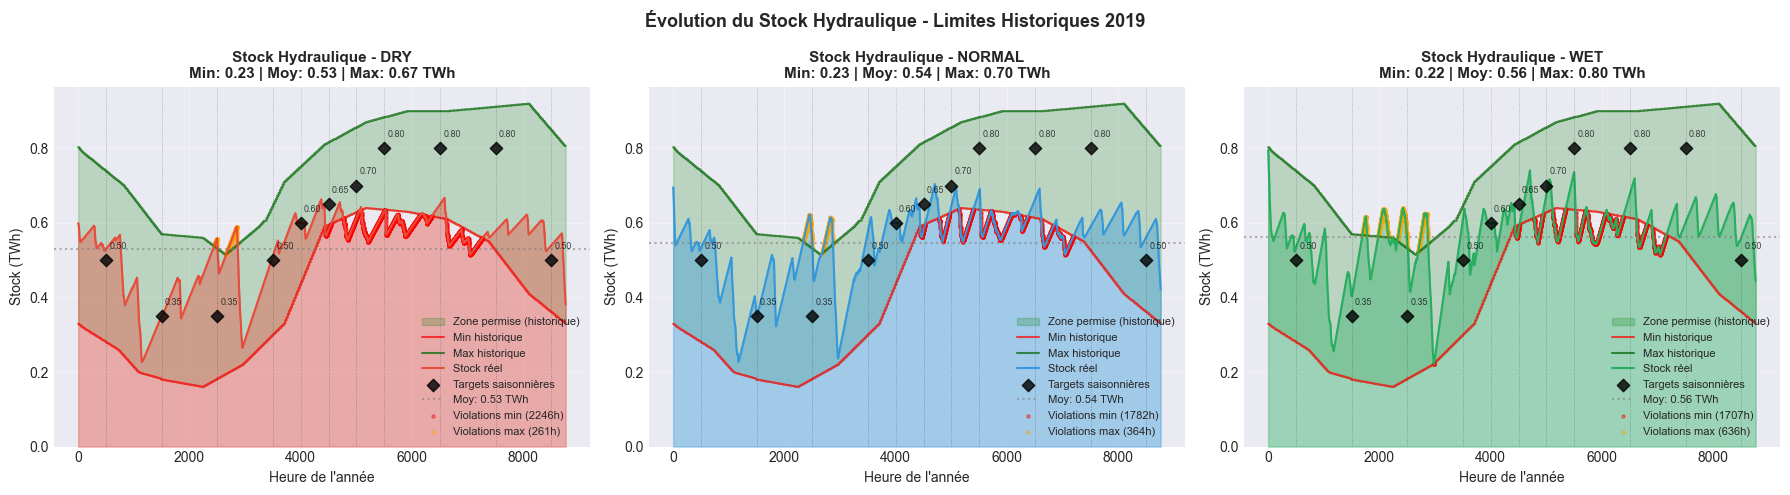


⚠️  VIOLATIONS DES CONTRAINTES DE STOCK

DRY
  Violations MIN :  2246 heures (25.64%)
  Violations MAX :   261 heures (2.98%)
  ❌ MAUVAIS - Violations importantes

NORMAL
  Violations MIN :  1782 heures (20.34%)
  Violations MAX :   364 heures (4.16%)
  ❌ MAUVAIS - Violations importantes

WET
  Violations MIN :  1707 heures (19.49%)
  Violations MAX :   636 heures (7.26%)
  ❌ MAUVAIS - Violations importantes


In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# ===== CHARGER LES LIMITES HISTORIQUES =====
excel_file = '../data/Donnees_etude_de_cas_ETE305.xlsx'

# Charger directement depuis les cellules Excel
wb = load_workbook(excel_file)
ws = wb['Stock hydro']  # Ou le vrai nom de la feuille

lev_low = []
lev_high = []
dates = []

for row in range(4, 369):  # B4:B368 = 365 lignes
    lev_low.append(ws[f'B{row}'].value)
    lev_high.append(ws[f'C{row}'].value)
    dates.append(ws[f'A{row}'].value)

# Convertir en array
lev_low = np.array(lev_low, dtype=float)
lev_high = np.array(lev_high, dtype=float)
dates = np.array(dates)

# Convertir % en TWh (capacité = 1 TWh)
stock_min_histor_daily = (lev_low / 100) * 1.0
stock_max_histor_daily = (lev_high / 100) * 1.0

HYDRO_SHIFT_DAYS = 181

# Recaler les limites journalières (comme recale_hydro_values en Julia)
stock_min_histor_daily = np.roll(stock_min_histor_daily, -HYDRO_SHIFT_DAYS)
stock_max_histor_daily = np.roll(stock_max_histor_daily, -HYDRO_SHIFT_DAYS)

print(f"✅ Limites historiques chargées : {len(lev_low)} jours")
print(f"   Min: {lev_low.min():.1f}% - {lev_low.max():.1f}%")
print(f"   Max: {lev_high.min():.1f}% - {lev_high.max():.1f}%")

# ===== GRAPHIQUES =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    # Stock réel (horaire) en TWh
    stock = df['stock_hydro'].values / 1e6
    hours = np.arange(len(stock))
    
    # Étendre les limites journalières sur 8760 heures
    # Chaque jour a 24 heures
    stock_min_histor = np.repeat(stock_min_histor_daily, 24)[:len(stock)]
    stock_max_histor = np.repeat(stock_max_histor_daily, 24)[:len(stock)]
    
    # Zone permise (historique)
    ax.fill_between(hours, stock_min_histor, stock_max_histor, alpha=0.2, color='green', label='Zone permise (historique)')
    ax.plot(hours, stock_min_histor, 'r-', linewidth=1.5, alpha=0.7, label='Min historique')
    ax.plot(hours, stock_max_histor, 'darkgreen', linewidth=1.5, alpha=0.7, label='Max historique')
    
    # Stock réel
    ax.fill_between(hours, 0, stock, alpha=0.4, color=colors[scenario])
    ax.plot(hours, stock, color=colors[scenario], linewidth=1.5, label='Stock réel')

    SEASONAL_TARGETS = {
            "target_1": {"hour": 500,  "dry": 0.50, "normal": 0.50, "wet": 0.50},
            "target_2": {"hour": 1500, "dry": 0.35, "normal": 0.35, "wet": 0.35},
            "target_3": {"hour": 2500, "dry": 0.35, "normal": 0.35, "wet": 0.35},
            "target_4": {"hour": 3500, "dry": 0.50, "normal": 0.50, "wet": 0.50},
            "target_45": {"hour": 4000, "dry": 0.60, "normal": 0.60, "wet": 0.60},
            "target_5": {"hour": 4500, "dry": 0.65, "normal": 0.65, "wet": 0.65},
            "target_55": {"hour": 5000, "dry": 0.70, "normal": 0.70, "wet": 0.70},
            "target_6": {"hour": 5500, "dry": 0.80, "normal": 0.80, "wet": 0.80},
            "target_7": {"hour": 6500, "dry": 0.80, "normal": 0.80, "wet": 0.80},
            "target_8": {"hour": 7500, "dry": 0.80, "normal": 0.80, "wet": 0.80},
            "target_9": {"hour": 8500, "dry": 0.50, "normal": 0.50, "wet": 0.50},
        }

    target_hours  = [t["hour"]       for t in SEASONAL_TARGETS.values()]
    target_values = [t[scenario]     for t in SEASONAL_TARGETS.values()]

    ax.scatter(target_hours, target_values,
               color='black', marker='D', s=40, zorder=5,
               label='Targets saisonnières', alpha=0.8)

    for h, v in zip(target_hours, target_values):
        ax.axvline(x=h, color='black', linestyle=':', linewidth=0.6, alpha=0.3)
        ax.annotate(f'{v:.2f}', xy=(h, v), xytext=(h+60, v+0.03),
                    fontsize=6.5, color='black', alpha=0.7)
    
    # Moyenne
    ax.axhline(y=stock.mean(), color='gray', linestyle=':', linewidth=1.5, alpha=0.6, label=f'Moy: {stock.mean():.2f} TWh')
    
    # Violations
    violations_min = stock < stock_min_histor
    violations_max = stock > stock_max_histor
    
    if violations_min.any():
        ax.scatter(hours[violations_min], stock[violations_min], color='red', s=5, alpha=0.4, label=f'Violations min ({violations_min.sum()}h)')
    if violations_max.any():
        ax.scatter(hours[violations_max], stock[violations_max], color='orange', s=5, alpha=0.4, label=f'Violations max ({violations_max.sum()}h)')
    
    ax.set_title(f'Stock Hydraulique - {scenario.upper()}\nMin: {stock.min():.2f} | Moy: {stock.mean():.2f} | Max: {stock.max():.2f} TWh',
                fontweight='bold', fontsize=11)
    ax.set_ylabel('Stock (TWh)', fontsize=10)
    ax.set_xlabel('Heure de l\'année', fontsize=10)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('Évolution du Stock Hydraulique - Limites Historiques 2019', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ===== RÉSUMÉ VIOLATIONS =====
print("\n" + "="*100)
print("⚠️  VIOLATIONS DES CONTRAINTES DE STOCK")
print("="*100)

for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    
    df = results[scenario]
    stock = df['stock_hydro'].values / 1e6
    
    stock_min_histor = np.repeat(stock_min_histor_daily, 24)[:len(stock)]
    stock_max_histor = np.repeat(stock_max_histor_daily, 24)[:len(stock)]
    
    violations_min = (stock < stock_min_histor).sum()
    violations_max = (stock > stock_max_histor).sum()
    
    print(f"\n{scenario.upper()}")
    print(f"  Violations MIN : {violations_min:5d} heures ({100*violations_min/len(stock):.2f}%)")
    print(f"  Violations MAX : {violations_max:5d} heures ({100*violations_max/len(stock):.2f}%)")
    
    if violations_min + violations_max == 0:
        print(f"  ✅ EXCELLENT - Contraintes bien respectées")
    elif violations_min + violations_max < 100:
        print(f"  ⚠️  BON - Quelques violations mineures")
    else:
        print(f"  ❌ MAUVAIS - Violations importantes")

## 3️⃣ PRODUCTION HYDRAULIQUE MENSUELLE (Lacs vs FDL)

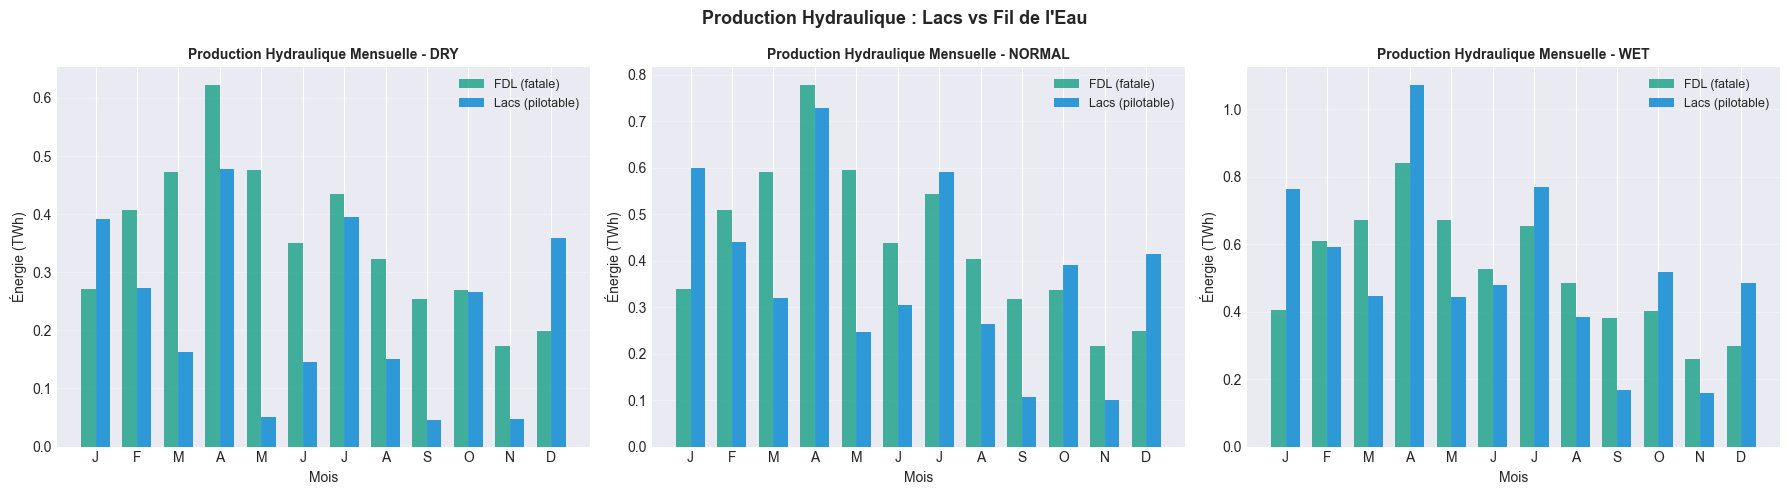

In [291]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    # Production mensuelle
    monthly_lac = df.groupby('month')['Phy_lac'].sum() / 1e6
    monthly_fdl = df.groupby('month')['Phy_fdl'].sum() / 1e6
    
    x = np.arange(1, 13)
    width = 0.35
    
    ax.bar(x - width/2, monthly_fdl.reindex(x, fill_value=0), width, label='FDL (fatale)', color='#16A085', alpha=0.8)
    ax.bar(x + width/2, monthly_lac.reindex(x, fill_value=0), width, label='Lacs (pilotable)', color='#0084D1', alpha=0.8)
    
    ax.set_title(f'Production Hydraulique Mensuelle - {scenario.upper()}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Énergie (TWh)', fontsize=10)
    ax.set_xlabel('Mois', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Production Hydraulique : Lacs vs Fil de l\'Eau', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4️⃣ MIX ÉNERGÉTIQUE ANNUEL

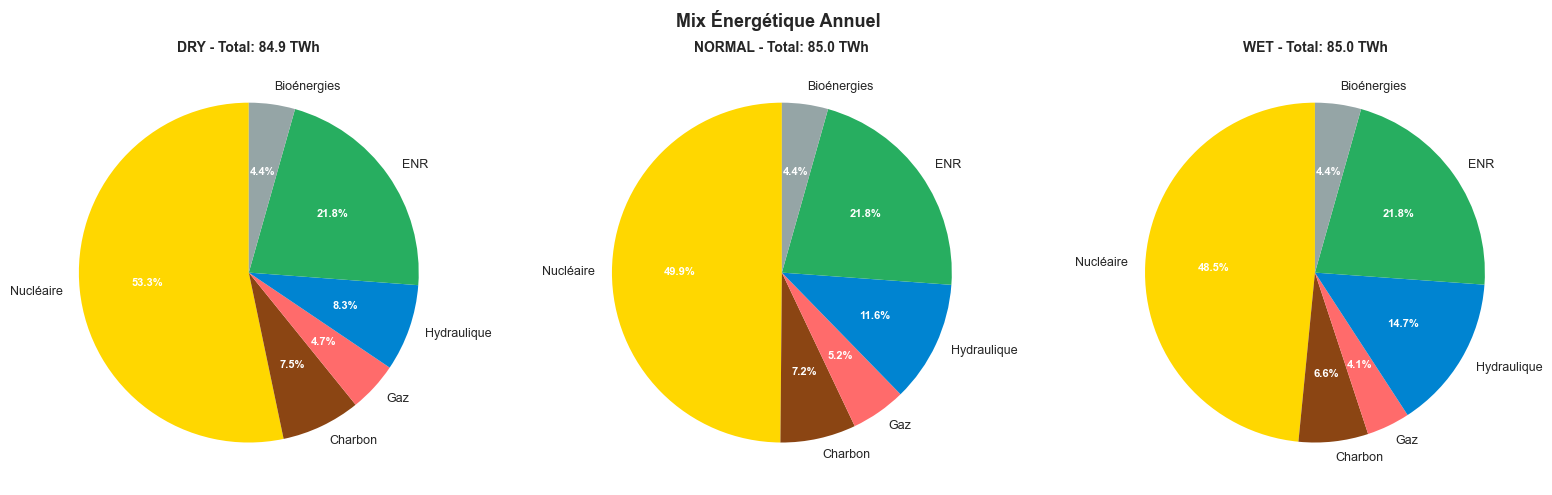

In [292]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    # Production par source
    p_nuc = df['P_nuc'].sum() / 1e6 if 'P_nuc' in df.columns else 0
    p_charbon = df['P_charbon'].sum() / 1e6 if 'P_charbon' in df.columns else 0
    p_ccg = df['P_ccg'].sum() / 1e6 if 'P_ccg' in df.columns else 0
    p_tac = df['P_tac'].sum() / 1e6 if 'P_tac' in df.columns else 0
    p_gaz = p_ccg + p_tac
    p_hydro = df['Phy_lac'].sum() / 1e6 + df['Phy_fdl'].sum() / 1e6 if all(c in df.columns for c in ['Phy_lac', 'Phy_fdl']) else 0
    p_eolien = df['P_eolien'].sum() / 1e6 if 'P_eolien' in df.columns else 0
    p_solaire = df['P_solaire'].sum() / 1e6 if 'P_solaire' in df.columns else 0
    p_bio = (df['P_dechets'].sum() + df['P_biomasse'].sum()) / 1e6 if all(c in df.columns for c in ['P_dechets', 'P_biomasse']) else 0
    
    productions = [p_nuc, p_charbon, p_gaz, p_hydro, p_eolien + p_solaire, p_bio]
    labels = ['Nucléaire', 'Charbon', 'Gaz', 'Hydraulique', 'ENR', 'Bioénergies']
    colors_pie = ['#FFD700', '#8B4513', '#FF6B6B', '#0084D1', '#27AE60', '#95A5A6']
    
    # Créer le pie chart
    wedges, texts, autotexts = ax.pie(
        productions, 
        labels=labels, 
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=90,
        textprops={'fontsize': 9}
    )
    
    # Mettre en gras les pourcentages
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(8)
    
    total = sum(productions)
    ax.set_title(f'{scenario.upper()} - Total: {total:.1f} TWh', fontweight='bold', fontsize=10)

plt.suptitle('Mix Énergétique Annuel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5️⃣ VIOLATIONS STOCK (Slack Min/Max)

In [293]:
print("\n" + "="*100)
print("⚠️  VIOLATIONS DES CONTRAINTES DE STOCK HYDRAULIQUE")
print("="*100)

for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    
    df = results[scenario]
    
    if 'slack_stock_min' not in df.columns or 'slack_stock_max' not in df.columns:
        print(f"\n{scenario.upper()} : Colonnes slack non disponibles")
        continue
    
    # Heures avec violations
    hours_slack_min = (df['slack_stock_min'] > 0).sum()
    hours_slack_max = (df['slack_stock_max'] > 0).sum()
    
    total_slack_min = df['slack_stock_min'].sum() / 1e6
    total_slack_max = df['slack_stock_max'].sum() / 1e6
    
    print(f"\n{scenario.upper()}")
    print("-" * 100)
    print(f"  Slack MIN (stock trop bas)      : {hours_slack_min:4d} heures | Total: {total_slack_min:8.4f} TWh")
    print(f"  Slack MAX (stock trop haut)     : {hours_slack_max:4d} heures | Total: {total_slack_max:8.4f} TWh")
    print(f"  TOTAL violations stock          : {total_slack_min + total_slack_max:8.4f} TWh")
    
    if total_slack_min + total_slack_max < 0.001:
        print(f"  ✅ EXCELLENT - Contraintes stock bien respectées")
    elif total_slack_min + total_slack_max < 0.01:
        print(f"  ⚠️  BON - Quelques violations mineures")
    else:
        print(f"  ❌ MAUVAIS - Violations importantes")


⚠️  VIOLATIONS DES CONTRAINTES DE STOCK HYDRAULIQUE

DRY
----------------------------------------------------------------------------------------------------
  Slack MIN (stock trop bas)      : 2687 heures | Total: 246.0796 TWh
  Slack MAX (stock trop haut)     :  665 heures | Total:  17.3547 TWh
  TOTAL violations stock          : 263.4344 TWh
  ❌ MAUVAIS - Violations importantes

NORMAL
----------------------------------------------------------------------------------------------------
  Slack MIN (stock trop bas)      : 2118 heures | Total: 174.3203 TWh
  Slack MAX (stock trop haut)     :  611 heures | Total:  15.1877 TWh
  TOTAL violations stock          : 189.5080 TWh
  ❌ MAUVAIS - Violations importantes

WET
----------------------------------------------------------------------------------------------------
  Slack MIN (stock trop bas)      : 1505 heures | Total:  96.2701 TWh
  Slack MAX (stock trop haut)     :  523 heures | Total:  12.0581 TWh
  TOTAL violations stock          

## 6️⃣ UTILISATION STEP

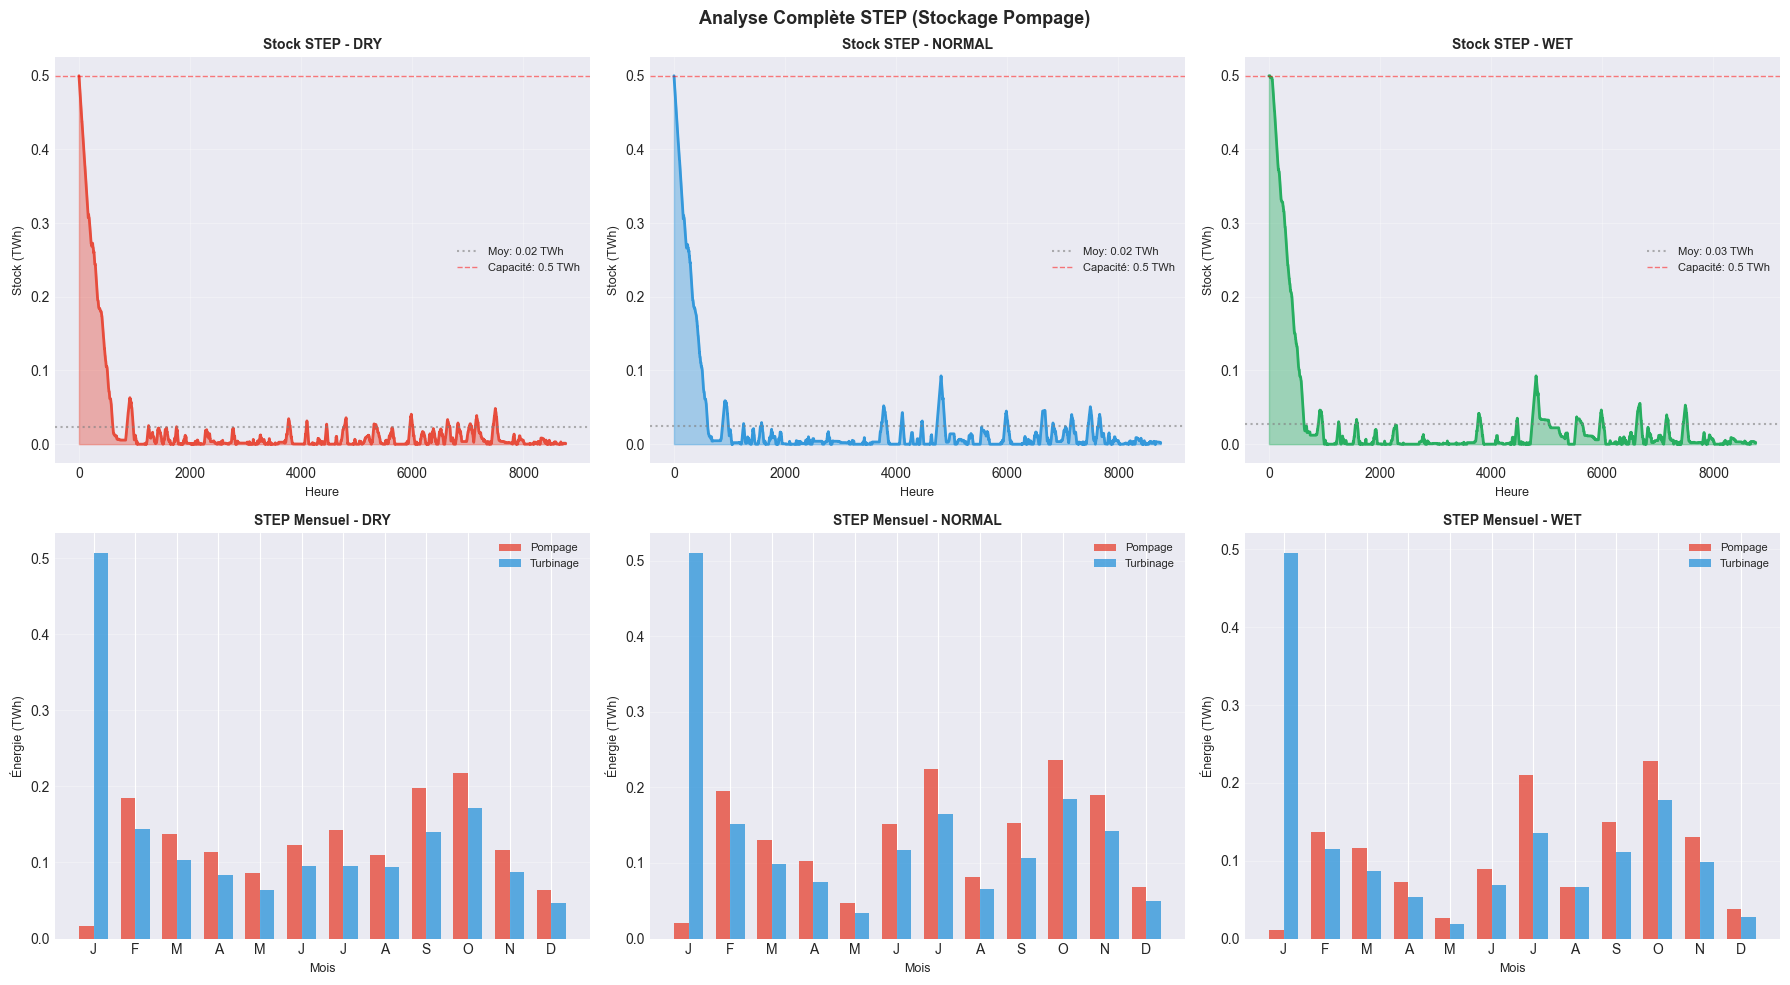


📊 RÉSUMÉ UTILISATION STEP

DRY
  Pompage total    :   1.51 TWh
  Turbinage total  :   1.63 TWh
  Stock moyen      :   0.02 TWh
  Efficacité       : 108.0% (rendement 75%)

NORMAL
  Pompage total    :   1.60 TWh
  Turbinage total  :   1.70 TWh
  Stock moyen      :   0.02 TWh
  Efficacité       : 106.1% (rendement 75%)

WET
  Pompage total    :   1.27 TWh
  Turbinage total  :   1.45 TWh
  Stock moyen      :   0.03 TWh
  Efficacité       : 114.2% (rendement 75%)


In [294]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    
    # ===== Stock STEP =====
    ax = axes[0, idx]
    
    if 'stock_STEP' in df.columns:
        stock_step = df['stock_STEP'].values / 1e6
        hours = np.arange(len(stock_step))
        
        ax.fill_between(hours, 0, stock_step, alpha=0.4, color=colors[scenario])
        ax.plot(hours, stock_step, color=colors[scenario], linewidth=2)
        ax.axhline(y=stock_step.mean(), color='gray', linestyle=':', linewidth=1.5, alpha=0.6, label=f'Moy: {stock_step.mean():.2f} TWh')
        ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Capacité: 0.5 TWh')
        
        ax.set_title(f'Stock STEP - {scenario.upper()}', fontweight='bold', fontsize=10)
        ax.set_ylabel('Stock (TWh)', fontsize=9)
        ax.set_xlabel('Heure', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Colonne STEP non disponible', ha='center', va='center', transform=ax.transAxes)
    
    # ===== Pompage/Turbinage STEP mensuel =====
    ax = axes[1, idx]
    
    if 'Pcharge_STEP' in df.columns and 'Pdecharge_STEP' in df.columns:
        monthly_pump = df.groupby('month')['Pcharge_STEP'].sum() / 1e6
        monthly_turb = df.groupby('month')['Pdecharge_STEP'].sum() / 1e6
        
        x = np.arange(1, 13)
        width = 0.35
        
        ax.bar(x - width/2, monthly_pump.reindex(x, fill_value=0), width, label='Pompage', color='#E74C3C', alpha=0.8)
        ax.bar(x + width/2, monthly_turb.reindex(x, fill_value=0), width, label='Turbinage', color='#3498DB', alpha=0.8)
        
        ax.set_title(f'STEP Mensuel - {scenario.upper()}', fontweight='bold', fontsize=10)
        ax.set_ylabel('Énergie (TWh)', fontsize=9)
        ax.set_xlabel('Mois', fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, 'Colonnes STEP non disponibles', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Analyse Complète STEP (Stockage Pompage)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé STEP
print("\n" + "="*100)
print("📊 RÉSUMÉ UTILISATION STEP")
print("="*100)
for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    df = results[scenario]
    
    pump_total = df['Pcharge_STEP'].sum() / 1e6 if 'Pcharge_STEP' in df.columns else 0
    turb_total = df['Pdecharge_STEP'].sum() / 1e6 if 'Pdecharge_STEP' in df.columns else 0
    stock_mean = df['stock_STEP'].mean() / 1e6 if 'stock_STEP' in df.columns else 0
    
    print(f"\n{scenario.upper()}")
    print(f"  Pompage total    : {pump_total:6.2f} TWh")
    print(f"  Turbinage total  : {turb_total:6.2f} TWh")
    print(f"  Stock moyen      : {stock_mean:6.2f} TWh")
    print(f"  Efficacité       : {100*turb_total/pump_total:.1f}% (rendement 75%)" if pump_total > 0 else "  Pas d'utilisation STEP")

## 7️⃣ FIABILITÉ ET DÉFAILLANCES


🚨 DÉFAILLANCES ÉLECTRIQUES (Puns)

DRY
  Défaillance totale   : 0.1314 TWh
  Heures défaillance   :   92 heures
  Fiabilité            :  99.85%
  ⚠️  Acceptable

NORMAL
  Défaillance totale   : 0.2800 TWh
  Heures défaillance   :  161 heures
  Fiabilité            :  99.67%
  ⚠️  Acceptable

WET
  Défaillance totale   : 0.3658 TWh
  Heures défaillance   :  201 heures
  Fiabilité            :  99.57%
  ⚠️  Acceptable


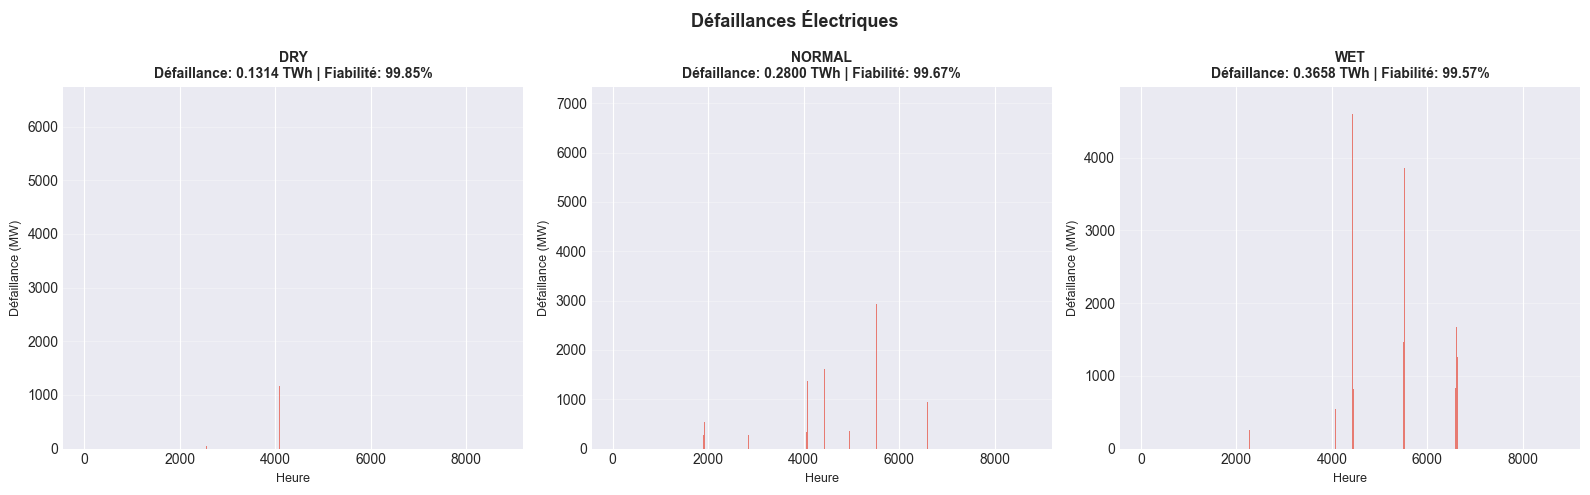

In [295]:
print("\n" + "="*100)
print("🚨 DÉFAILLANCES ÉLECTRIQUES (Puns)")
print("="*100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    if 'Puns' not in df.columns:
        ax.text(0.5, 0.5, 'Colonne Puns non disponible', ha='center', va='center', transform=ax.transAxes)
        continue
    
    puns = df['Puns'].values
    puns_twh = puns.sum() / 1e6
    hours_defaillance = (puns > 0).sum()
    charge_total = df['load'].sum() / 1e6
    fiabilite = 100 * (1 - puns_twh / charge_total)
    
    # Graphique
    hours = np.arange(len(puns))
    ax.bar(hours, puns, width=1, color='#E74C3C', alpha=0.7)
    
    ax.set_title(f'{scenario.upper()}\nDéfaillance: {puns_twh:.4f} TWh | Fiabilité: {fiabilite:.2f}%',
                fontweight='bold', fontsize=10)
    ax.set_ylabel('Défaillance (MW)', fontsize=9)
    ax.set_xlabel('Heure', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Détails
    print(f"\n{scenario.upper()}")
    print(f"  Défaillance totale   : {puns_twh:.4f} TWh")
    print(f"  Heures défaillance   : {hours_defaillance:4d} heures")
    print(f"  Fiabilité            : {fiabilite:6.2f}%")
    if fiabilite >= 99.99:
        print(f"  ✅ Excellent")
    elif fiabilite >= 99:
        print(f"  ⚠️  Acceptable")
    else:
        print(f"  ❌ À améliorer")

plt.suptitle('Défaillances Électriques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8️⃣ ENGAGEMENTS UNITÉS THERMIQUES

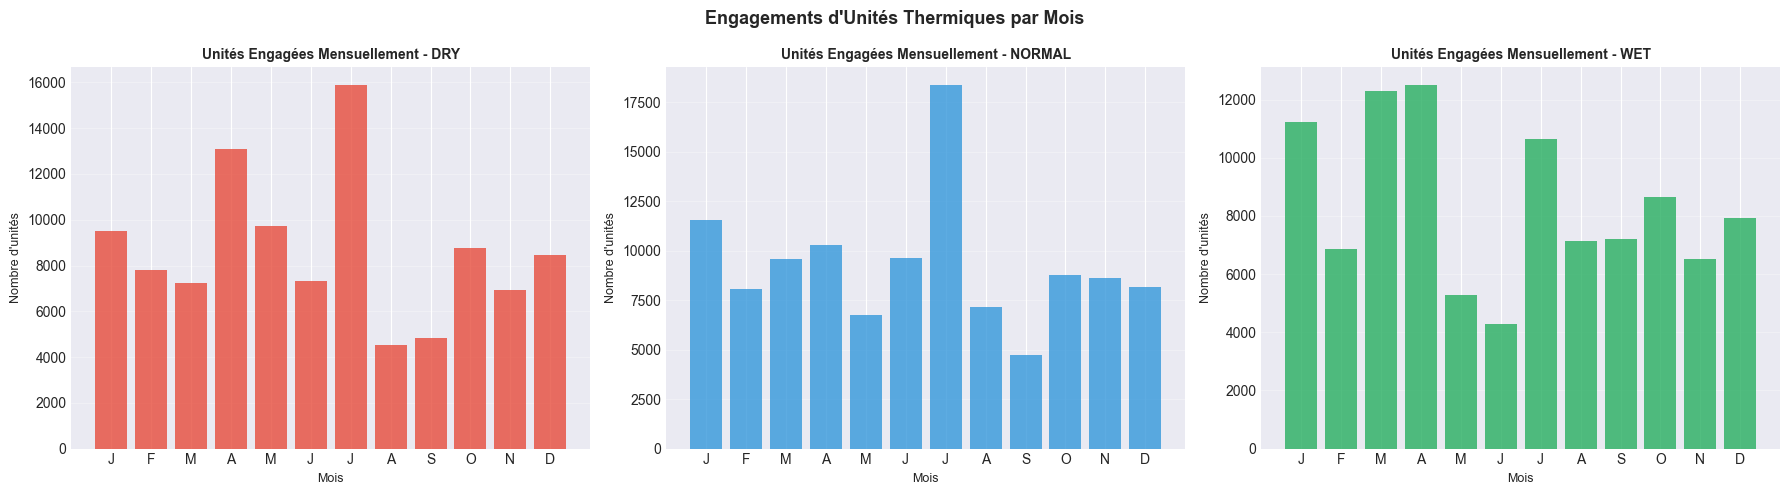

In [296]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    # Nombre d'unités engagées
    uc_columns = [c for c in df.columns if c.startswith('UC_')]
    
    if not uc_columns:
        ax.text(0.5, 0.5, 'Colonnes UC non disponibles', ha='center', va='center', transform=ax.transAxes)
        continue
    
    total_uc = sum(df[col] for col in uc_columns if col in df.columns)
    total_uc_monthly = df.groupby('month')[uc_columns].sum().sum(axis=1) if uc_columns else None
    
    if total_uc_monthly is not None:
        x = np.arange(1, 13)
        ax.bar(x, total_uc_monthly.reindex(x, fill_value=0), color=colors[scenario], alpha=0.8)
        
        ax.set_title(f'Unités Engagées Mensuellement - {scenario.upper()}', fontweight='bold', fontsize=10)
        ax.set_ylabel('Nombre d\'unités', fontsize=9)
        ax.set_xlabel('Mois', fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
        ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, 'Pas d\'engagements', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Engagements d\'Unités Thermiques par Mois', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9️⃣ COMPARAISON APPORTS vs PRODUCTION HYDRAULIQUE

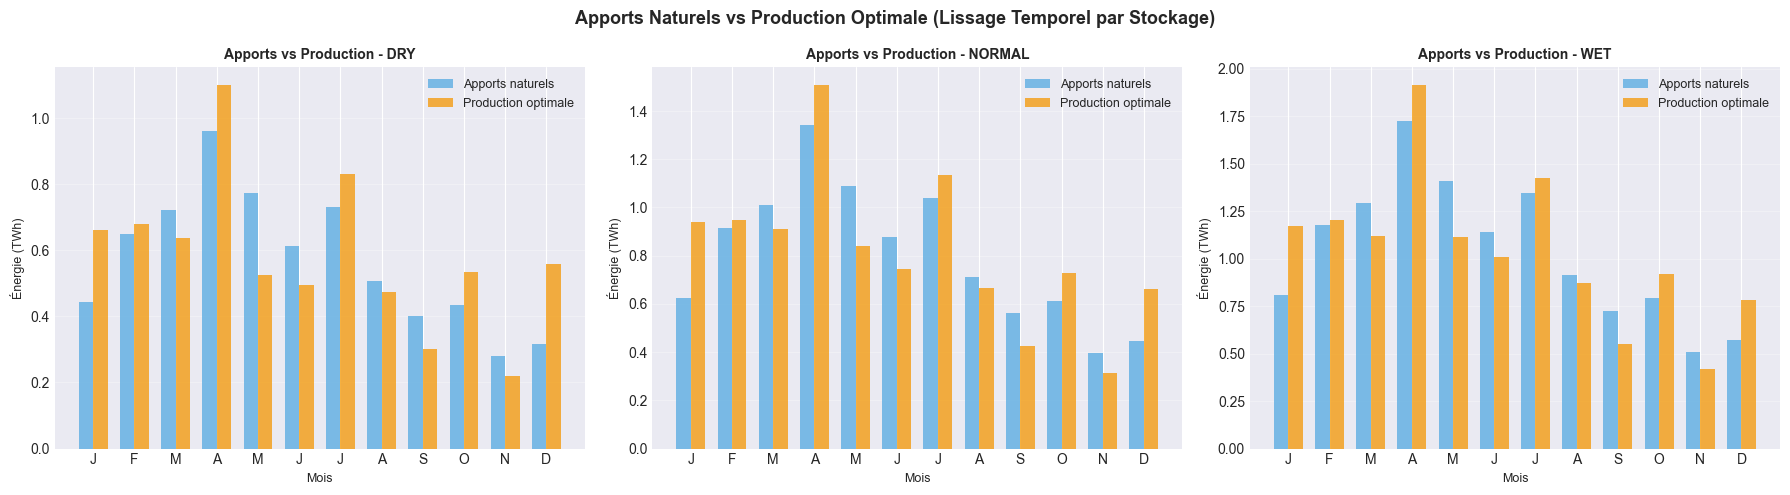

In [297]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    if 'inflows_lac' not in df.columns or 'inflows_fdl' not in df.columns:
        ax.text(0.5, 0.5, 'Colonnes inflows non disponibles', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # Apports et productions mensuels
    monthly_inflows = (df.groupby('month')['inflows_lac'].sum() + df.groupby('month')['inflows_fdl'].sum()) / 1e6
    monthly_production = (df.groupby('month')['Phy_lac'].sum() + df.groupby('month')['Phy_fdl'].sum()) / 1e6
    
    x = np.arange(1, 13)
    width = 0.35
    
    ax.bar(x - width/2, monthly_inflows.reindex(x, fill_value=0), width, label='Apports naturels', color='#5DADE2', alpha=0.8)
    ax.bar(x + width/2, monthly_production.reindex(x, fill_value=0), width, label='Production optimale', color='#F39C12', alpha=0.8)
    
    ax.set_title(f'Apports vs Production - {scenario.upper()}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Énergie (TWh)', fontsize=9)
    ax.set_xlabel('Mois', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Apports Naturels vs Production Optimale (Lissage Temporel par Stockage)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔟 RÉSUMÉ COMPARATIF FINAL

In [298]:
print("\n" + "="*100)
print("📊 RÉSUMÉ COMPARATIF - DRY vs NORMAL vs WET")
print("="*100)

# Créer tableau comparatif
comparison = pd.DataFrame({
    'DRY': [
        f"{summary['dry']['charge_twh']:.2f} TWh" if 'dry' in summary else 'N/A',
        f"{summary['dry']['hydro_total']:.2f} TWh ({100*summary['dry']['hydro_total']/summary['dry']['charge_twh']:.1f}%)" if 'dry' in summary else 'N/A',
        f"{summary['dry']['puns']:.4f} TWh" if 'dry' in summary else 'N/A',
        f"{summary['dry']['fiabilite']:.2f}%" if 'dry' in summary else 'N/A',
        f"{summary['dry']['stock_hydro_mean']:.2f} TWh" if 'dry' in summary else 'N/A',
        f"{summary['dry']['step_turb']:.2f} TWh" if 'dry' in summary else 'N/A',
    ],
    'NORMAL': [
        f"{summary['normal']['charge_twh']:.2f} TWh" if 'normal' in summary else 'N/A',
        f"{summary['normal']['hydro_total']:.2f} TWh ({100*summary['normal']['hydro_total']/summary['normal']['charge_twh']:.1f}%)" if 'normal' in summary else 'N/A',
        f"{summary['normal']['puns']:.4f} TWh" if 'normal' in summary else 'N/A',
        f"{summary['normal']['fiabilite']:.2f}%" if 'normal' in summary else 'N/A',
        f"{summary['normal']['stock_hydro_mean']:.2f} TWh" if 'normal' in summary else 'N/A',
        f"{summary['normal']['step_turb']:.2f} TWh" if 'normal' in summary else 'N/A',
    ],
    'WET': [
        f"{summary['wet']['charge_twh']:.2f} TWh" if 'wet' in summary else 'N/A',
        f"{summary['wet']['hydro_total']:.2f} TWh ({100*summary['wet']['hydro_total']/summary['wet']['charge_twh']:.1f}%)" if 'wet' in summary else 'N/A',
        f"{summary['wet']['puns']:.4f} TWh" if 'wet' in summary else 'N/A',
        f"{summary['wet']['fiabilite']:.2f}%" if 'wet' in summary else 'N/A',
        f"{summary['wet']['stock_hydro_mean']:.2f} TWh" if 'wet' in summary else 'N/A',
        f"{summary['wet']['step_turb']:.2f} TWh" if 'wet' in summary else 'N/A',
    ]
}, index=['Charge totale', 'Production hydraulique', 'Défaillance', 'Fiabilité', 'Stock hydro moy', 'STEP turbinage'])

print("\n" + comparison.to_string())
print("\n" + "="*100)


📊 RÉSUMÉ COMPARATIF - DRY vs NORMAL vs WET

                                    DRY            NORMAL                WET
Charge totale                 85.09 TWh         85.09 TWh          85.09 TWh
Production hydraulique  7.01 TWh (8.2%)  9.82 TWh (11.5%)  12.49 TWh (14.7%)
Défaillance                  0.1314 TWh        0.2800 TWh         0.3658 TWh
Fiabilité                        99.85%            99.67%             99.57%
Stock hydro moy                0.53 TWh          0.54 TWh           0.56 TWh
STEP turbinage                 1.63 TWh          1.70 TWh           1.45 TWh

